In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import statistics

years = range(2014,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k = 5

for year in years:
    file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
    with open(file_path, "rb") as f:
        graphs[f"graph_{year}"] = pickle.load(f)
                
        returns[year] = pd.read_parquet(f"../../data/02_clean/returns_new_{year}.parquet")
        returns[year] = np.log(1 + returns[year])

/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [2]:
df = pd.read_parquet("../../data/02_clean/df_metrics.parquet")

In [3]:
df_long = df[["year", "node", "hrm", "pozzi"]].rename(columns={
    "node":"stock", "hrm":"risk"
})

df_long

,year,stock,risk,pozzi
0,2014,A,-0.113502,0.162029
1,2014,AA,-0.242146,0.222550
2,2014,AAL,-0.411204,0.213583
3,2014,AAME,-0.566156,0.212748
4,2014,AAON,0.892336,0.186629
...,...,...,...,...
40657,2024,ZTS,-0.001498,0.140701
40658,2024,ZUMZ,0.723058,0.207884
40659,2024,ZVRA,-0.196636,0.189373
40660,2024,ZWS,0.349889,0.202001


In [4]:
import pandas as pd

# Mapeamento para identificar quem é o extremo superior (central) e inferior (peripheral)
centralities = {"central": "decil_10", "peripheral": "decil_1"}
portfolios = {}

for year in years:
    for centrality, decil_name in centralities.items():
        for metric in ["hrm", "pozzi"]:
            
            # 1. Carrega o arquivo salvo para descobrir as colunas (tickers)
            # Nota: Ajustei para ler .parquet já que no passo anterior salvamos como .parquet
            try:
                cols = pd.read_parquet(
                    f"../../data/06_portfolios/{decil_name}_{year}_{metric}.parquet"
                ).columns.tolist()
            except FileNotFoundError:
                print(f"Arquivo {decil_name}_{year}_{metric}.parquet não encontrado. Pulando...")
                continue

            # 2. Busca o histórico de retornos usando os tickers encontrados
            # A chave final será exatamente como você pediu: ex: "central_2024_hrm" ou "peripheral_2024_pozzi"
            chave_portfolio = f"{centrality}_{year}_{metric}"
            
            try:
                portfolios[chave_portfolio] = pd.read_parquet(
                    f"../../data/02_clean/returns_new_{year-k}_{year}.parquet"
                )[cols]
            except Exception:
                try:
                    portfolios[chave_portfolio] = pd.read_parquet(
                        f"../../data/02_clean/returns_new_{year-k+1}_{year}.parquet"
                    )[cols]
                except FileNotFoundError:
                    print(f"Não foi possível encontrar o arquivo de retornos para {chave_portfolio}.")

In [ ]:
from matplotlib.lines import Line2D

# Adaptado para suportar até 12 anos (grade 3x4)
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
metric = "hrm"

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}_{metric}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}_{metric}"].columns)

    

    central_color = "#22125F"
    peripheral_color = "#2E5C6E"
    middle_color = "#E5E5E5"
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append(central_color)       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append(peripheral_color)       # green = low risk / peripheral
        else:
            node_colors.append(middle_color)       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    # labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    # nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=28, fontweight="bold")
    ax.axis("off")

# Ocultar eixos extras se houver menos anos que subplots
for ax in axes.flat[len(years):]:
    ax.set_visible(False)

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=central_color, markersize=10, label="Central"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=peripheral_color, markersize=10, label="Peripheral"),
    # Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=28,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

fig.suptitle(f"Temporal Network Evolution — Central vs. Peripheral ({'HCM' if metric == 'hrm' else 'POZZI'})", fontsize=38, fontweight="bold", y=1.03)
os.makedirs(f"../../figures/window_{k}", exist_ok=True)
plt.savefig(f"../../figures/window_{k}/graphs.png", dpi=300)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

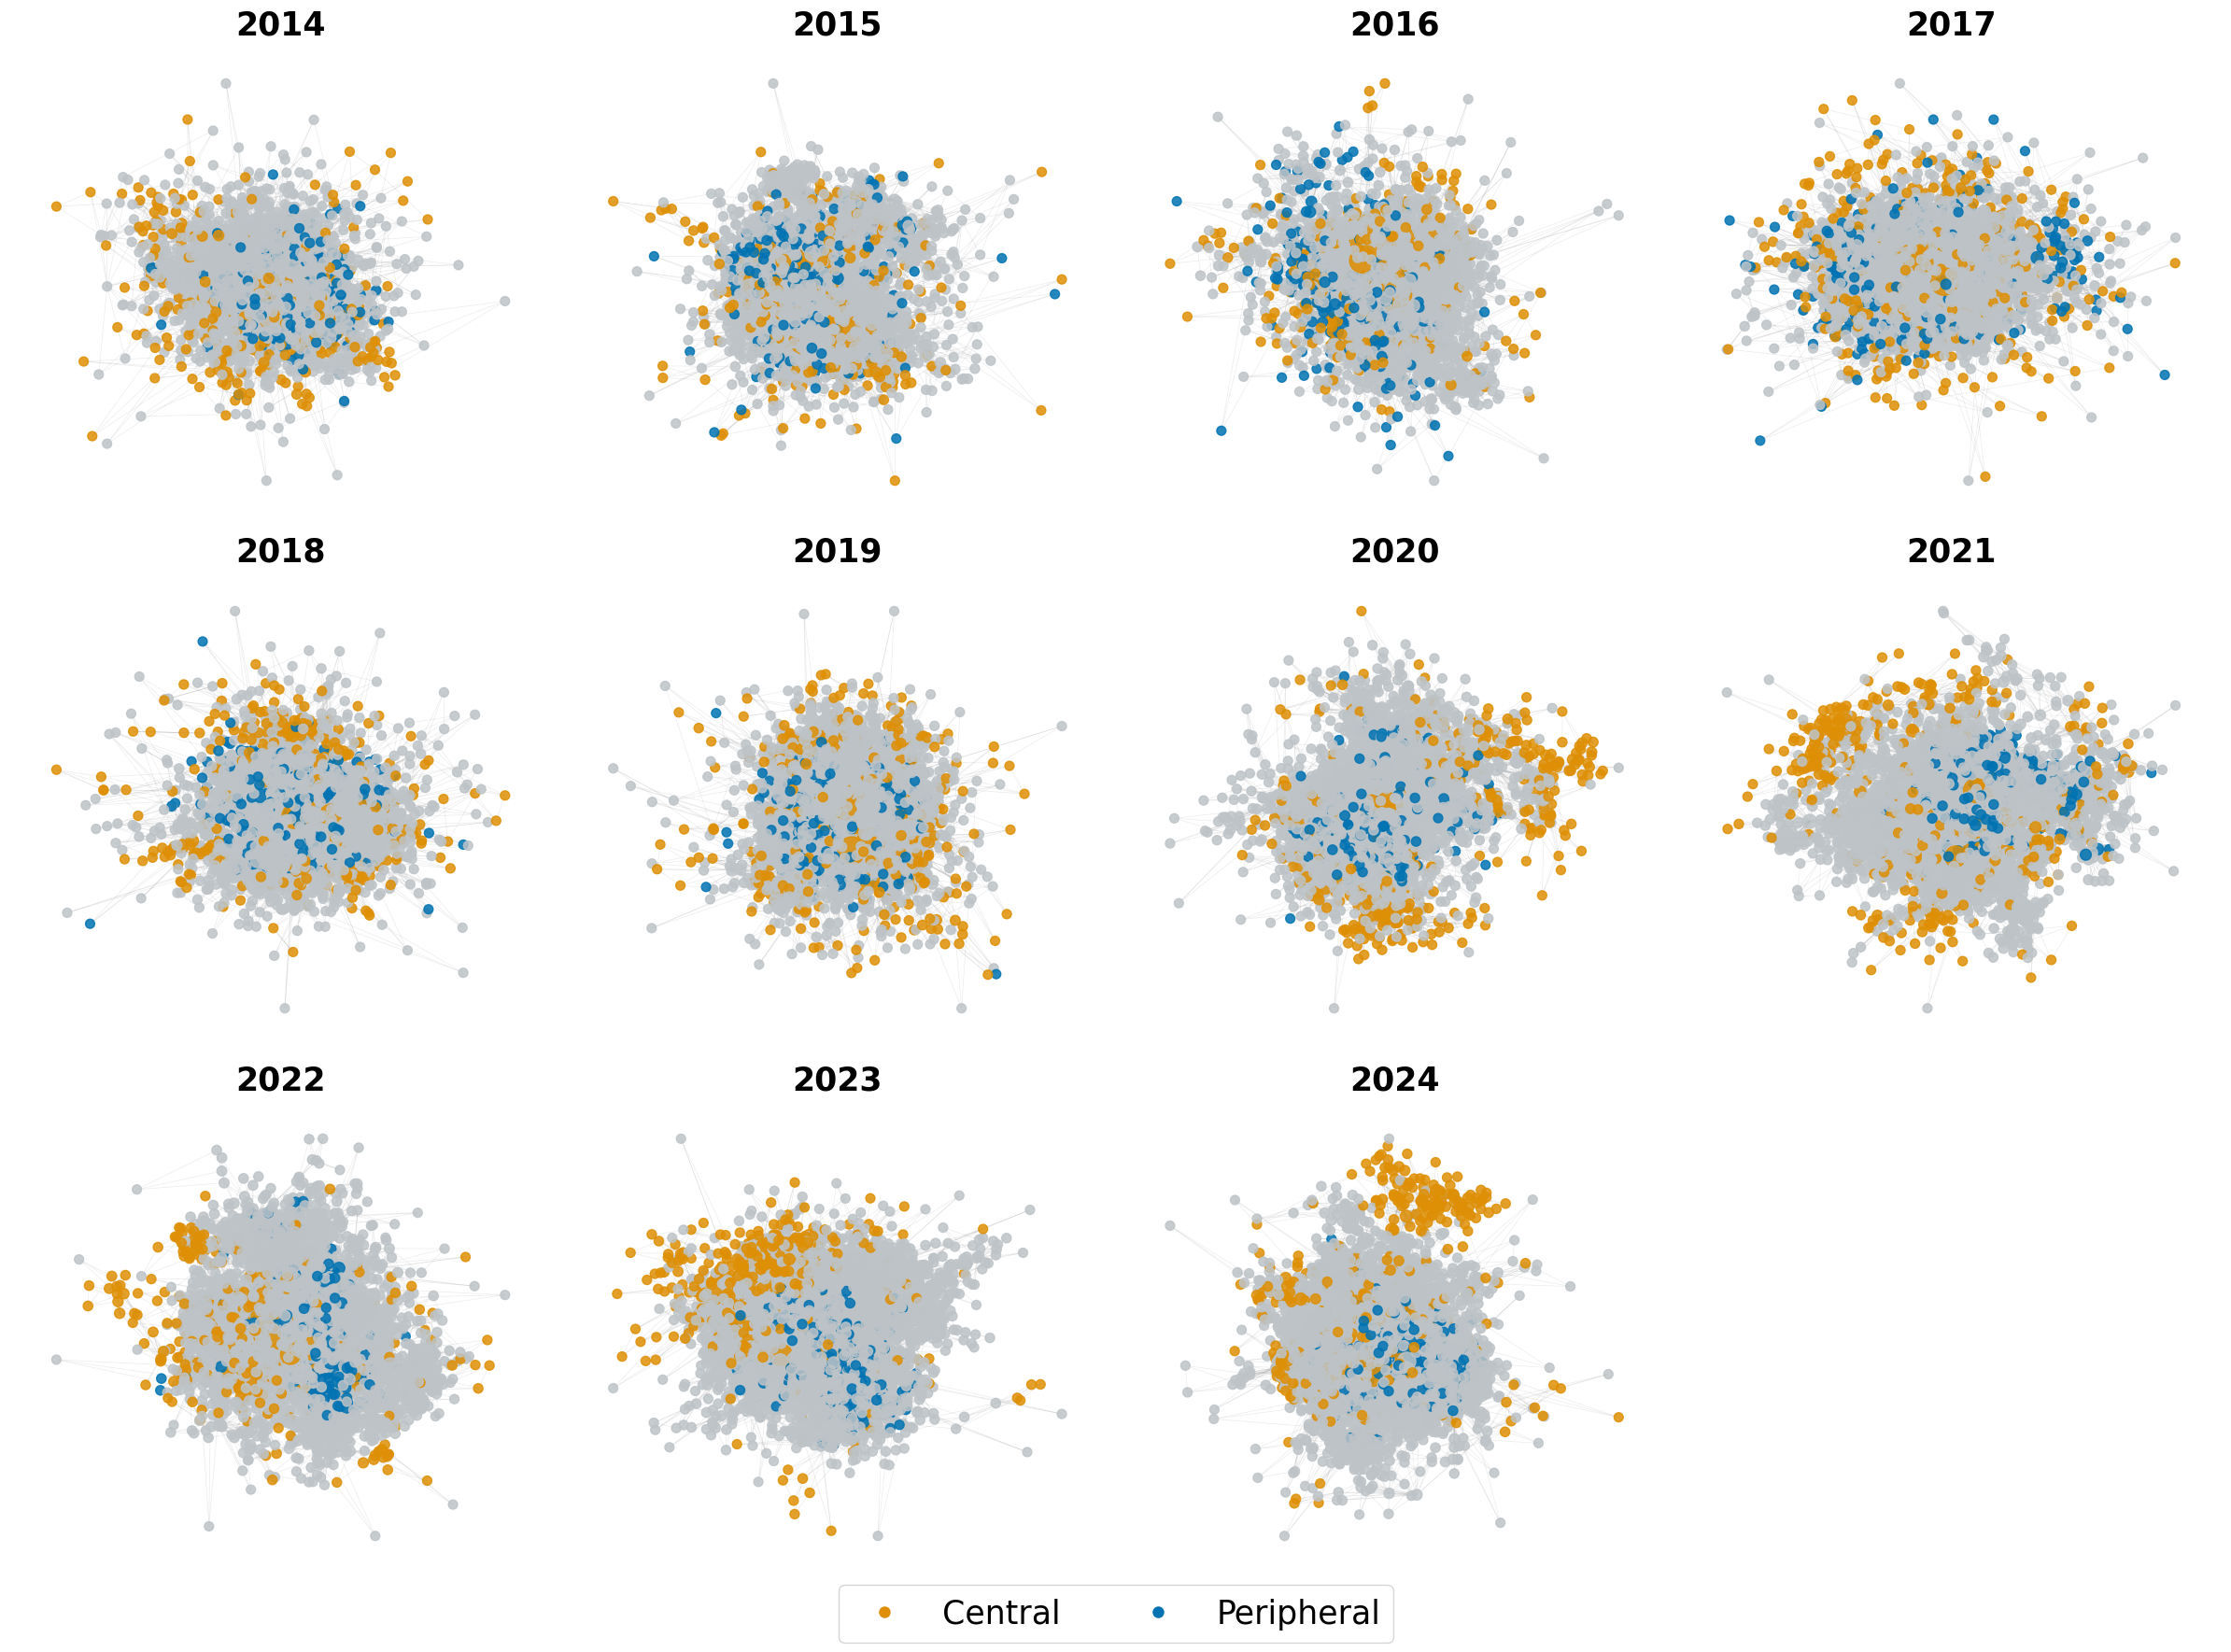

In [ ]:
from matplotlib.lines import Line2D

# Adaptado para suportar até 12 anos (grade 3x4)
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
metric = "pozzi"

for ax, year in zip(axes.flat, years):
    G = graphs[f"graph_{year}"]
    
    # Get portfolio membership for this year
    central_tickers    = set(portfolios[f"central_{year}_{metric}"].columns)
    peripheral_tickers = set(portfolios[f"peripheral_{year}_{metric}"].columns)

    

    central_color = "#22125F"
    peripheral_color = "#2E5C6E"
    middle_color = "#E5E5E5"
    
    # Assign colors
    node_colors = []
    for node in G.nodes():
        if node in central_tickers:
            node_colors.append(central_color)       # red  = high risk / central
        elif node in peripheral_tickers:
            node_colors.append(peripheral_color)       # green = low risk / peripheral
        else:
            node_colors.append(middle_color)       # grey = middle

    node_sizes = []
    degree = dict(G.degree(weight="weight"))
    max_deg = max(degree.values())
    for node in G.nodes():
        node_sizes.append(50 + 400 * (degree[node] / max_deg))  # scale by weighted degree

    # Layout — spring layout seeded for reproducibility
    pos = nx.spring_layout(G, seed=42, k=0.4)

    # Draw edges (light grey, thin)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           alpha=0.85)

    # Labels only for central/peripheral nodes to avoid clutter
    # labels = {n: n for n in G.nodes() if n in central_tickers | peripheral_tickers}
    # nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=28, fontweight="bold")
    ax.axis("off")

# Ocultar eixos extras se houver menos anos que subplots
for ax in axes.flat[len(years):]:
    ax.set_visible(False)

# Shared legend
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=central_color, markersize=10, label="Central"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=peripheral_color, markersize=10, label="Peripheral"),
    # Line2D([0], [0], marker="o", color="w", markerfacecolor="#BDC3C7", markersize=10, label="Middle"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=28,
           bbox_to_anchor=(0.5, 0.01), frameon=True)

fig.suptitle(f"Temporal Network Evolution — Central vs. Peripheral ({'HCM' if metric == 'hrm' else 'POZZI'})", fontsize=38, fontweight="bold", y=1.03)
os.makedirs(f"../../figures/window_{k}", exist_ok=True)
plt.savefig(f"../../figures/window_{k}/graphs_{metric}.png", dpi=300)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()